In [1]:
import os
print(os.getcwd())

/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab


In [4]:
# Importaciones necesarias
import cv2
import matplotlib.pyplot as plt

def show_image(ruta_imagen):
    # 2. Carga la imagen con OpenCV
    img = cv2.imread(ruta_imagen)

    # 3. Validación de seguridad
    if img is None:
        print(f"❌ ERROR: No se pudo encontrar o leer la imagen en la ruta:\n{ruta_imagen}")
        print("Revisa que la ruta sea correcta o usa una ruta absoluta.")
    else:
        # 4. Convierte de BGR a RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 5. Configura y muestra
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.title("Imagen Original")
        plt.axis('off')
        plt.show()
    return img

def cargar_imagen(ruta_imagen, mostrar=False):
    """
    Carga una imagen, la valida y devuelve sus versiones en BGR y RGB.
    """
    img = cv2.imread(ruta_imagen)

    if img is None:
        print(f"❌ ERROR: No se pudo encontrar o leer la imagen en:\n{ruta_imagen}")
        return None, None

    # Crear la versión RGB para Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if mostrar:
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.title("Imagen Original")
        plt.axis('off')
        plt.show()

    return img, img_rgb

## Image - Bad Whiteboard

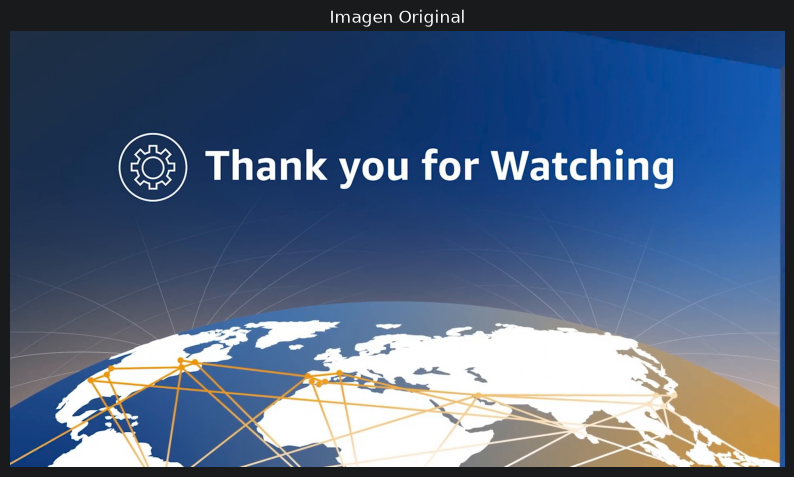

In [7]:
# 1. Define la ruta a tu imagen
ruta_imagen = '/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/bad_whiteboard/QJZHs1CSxu0.jpg' # Ajusta esto según las opciones de arriba
img = show_image(ruta_imagen)

## Analysing other Images

## pizarra_occlusion_filter

### Algoritmo

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualizar_filtro_oclusion(img, img_rgb):
    """
    Aplica el filtro de oclusión basado en intensidad y muestra el antes y después.
    """
    if img is None or img_rgb is None:
        print("❌ ERROR: No se pueden procesar imágenes nulas.")
        return

    h, w, c = img.shape
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Coordenadas ROI
    roi_x1, roi_x2 = int(w * 0.25), int(w * 0.75)
    roi_y1, roi_y2 = 200, 900
    roi = gray[roi_y1:roi_y2, roi_x1:roi_x2]

    # Filtro de intensidad
    col_means = np.mean(roi, axis=0)
    occluded_cols = col_means > 55.0

    # Crear copias para la visualización
    debug_img = img_rgb.copy()
    mask = np.zeros_like(img_rgb)

    # Dibujar las columnas ocluidas
    for x in range(roi_x1, roi_x2):
        col_idx = x - roi_x1
        if occluded_cols[col_idx]:
            # Máscara roja en RGB
            mask[roi_y1:roi_y2, x] = [255, 0, 0]

    # Aplicar la superposición (translucidez)
    cv2.addWeighted(mask, 0.3, debug_img, 1.0, 0, debug_img)

    # Dibujar el borde amarillo del ROI
    cv2.rectangle(debug_img, (roi_x1, roi_y1), (roi_x2, roi_y2), (255, 255, 0), 2)

    # Mostrar Antes y Después
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontsize=16)
    axes[0].axis('off')

    axes[1].imshow(debug_img)
    axes[1].set_title('Filtro de Oclusión Aplicado', fontsize=16)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

### Image

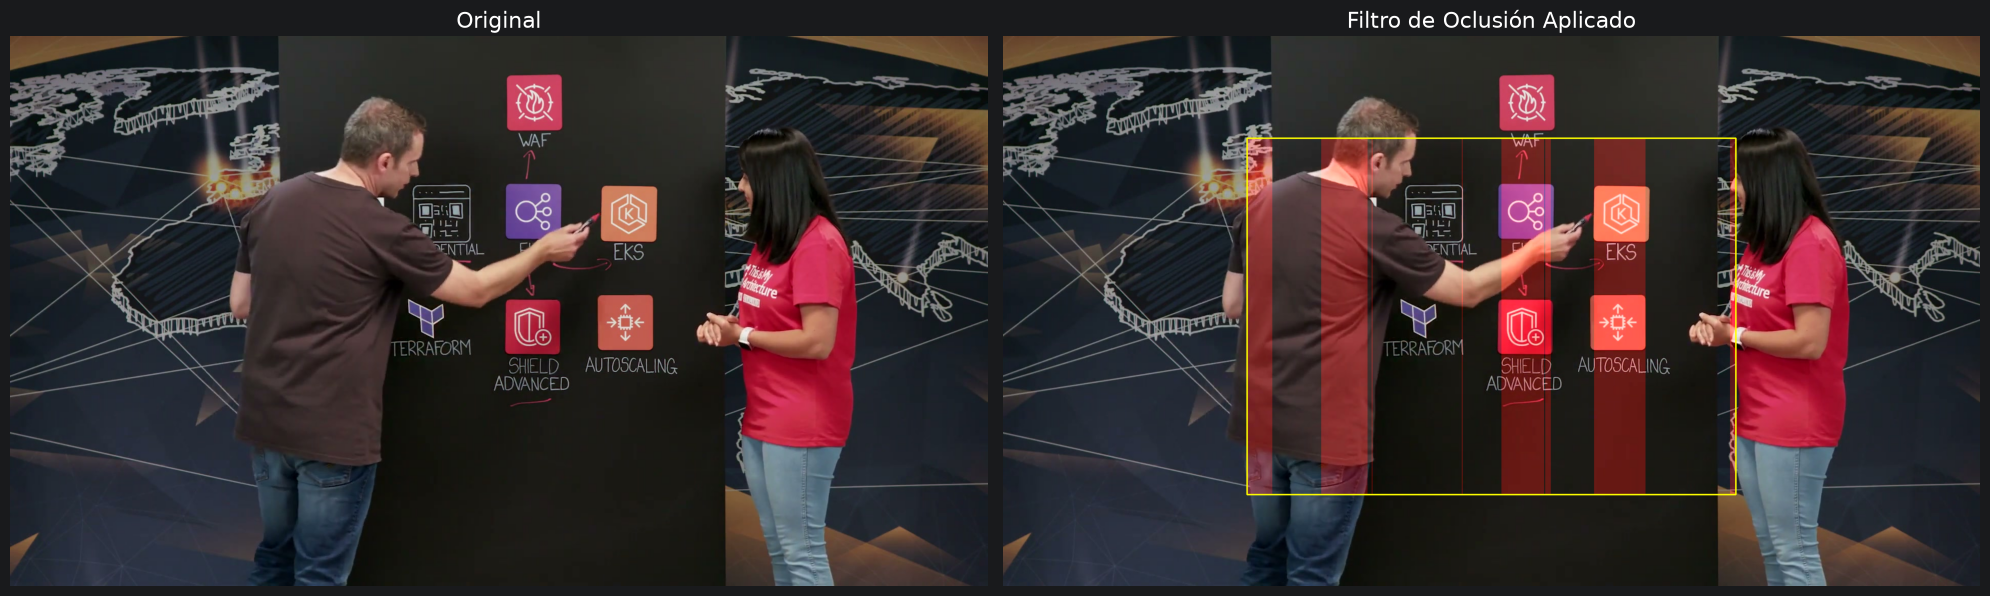

In [15]:
# 1. Define la ruta
ruta_imagen_2 = '/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/bad_whiteboard/1xLjtJnfZes.jpg'

# 2. Carga las variables (puedes poner mostrar=True si quieres ver solo la original primero)
imagen_bgr, imagen_rgb = cargar_imagen(ruta_imagen_2, mostrar=False)

# 3. Aplica y visualiza el filtro
visualizar_filtro_oclusion(imagen_bgr, imagen_rgb)

## pizarra_Template_Matching


En términos sencillos, este script es un buscador de íconos. Utiliza una técnica clásica de visión por computadora llamada Template Matching (coincidencia de plantillas).

Aquí tienes el desglose de su lógica:

Busca coincidencias: Toma una imagen principal (la pizarra) y un conjunto de imágenes pequeñas o "plantillas" (los íconos de los servicios de AWS). Luego, desliza cada plantilla sobre la imagen principal pixel por pixel para ver dónde hay una coincidencia visual (basado en un umbral de confianza, por defecto 90%).

Limpia los duplicados (NMS): Como el algoritmo a veces detecta el mismo ícono varias veces desplazado por unos pocos píxeles, usa una función llamada non_max_suppression (Supresión de No Máximos) para quedarse solo con el recuadro que tiene la puntuación más alta y borrar los superpuestos.

Selecciona al "ganador": En tu script original, procesa todos los frames de un video y elige como "mejor frame" aquel donde se haya detectado la mayor cantidad de íconos. Si hay un empate, elige el frame que aparece más tarde en el video (asumiendo que la arquitectura en la pizarra ya está terminada).

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def non_max_suppression(boxes: list[tuple[int, int, int, int, float]], overlap_thresh: float = 0.3) -> list[tuple[int, int, int, int, float]]:
    """
    Limpia las cajas delimitadoras superpuestas quedándose con la de mayor confianza.
    """
    if not boxes:
        return []

    boxes_arr = np.array(boxes, dtype=np.float32)
    x1, y1 = boxes_arr[:, 0], boxes_arr[:, 1]
    x2, y2 = boxes_arr[:, 2], boxes_arr[:, 3]
    scores = boxes_arr[:, 4]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h

        denom = (areas[i] + areas[order[1:]] - inter)
        iou = np.zeros_like(inter)
        valid = denom > 0
        iou[valid] = inter[valid] / denom[valid]

        inds = np.where(iou <= overlap_thresh)[0]
        order = order[inds + 1]

    return [boxes[i] for i in keep]

def visualizar_template_matching(img, img_rgb, ruta_templates_dir, threshold=0.85):
    """
    Aplica Template Matching a una imagen y visualiza los resultados con Matplotlib.
    """
    if img is None or img_rgb is None:
        print("❌ ERROR: La imagen es nula.")
        return

    # 1. Cargar las plantillas (íconos) desde la carpeta
    templates_dir = Path(ruta_templates_dir)
    template_paths = [p for p in templates_dir.glob("*") if p.suffix.lower() in [".png", ".jpg"] and p.name != "verify_crops.jpg"]

    if not template_paths:
        print(f"❌ ERROR: No se encontraron plantillas en {templates_dir}")
        return

    templates = {p.stem: cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) for p in template_paths}
    print(f"✅ Se cargaron {len(templates)} plantillas.")

    # 2. Preparar imagen
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    debug_img = img_rgb.copy()
    matched_count = 0

    # 3. Procesar cada plantilla
    for t_name, t_img in templates.items():
        if t_img is None:
            continue

        res = cv2.matchTemplate(img_gray, t_img, cv2.TM_CCOEFF_NORMED)
        res_dilated = cv2.dilate(res, np.ones((5, 5)))
        local_max = (res == res_dilated) & (res >= threshold)
        y_coords, x_coords = np.where(local_max)

        h_t, w_t = t_img.shape
        template_boxes = []
        for y, x in zip(y_coords, x_coords):
            score = float(res[y, x])
            template_boxes.append((x, y, x + w_t, y + h_t, score))

        # Limpiar duplicados
        keep_boxes = non_max_suppression(template_boxes, overlap_thresh=0.3)

        if keep_boxes:
            matched_count += 1
            # Dibujar los recuadros verdes en la imagen de visualización
            for bx1, by1, bx2, by2, bs in keep_boxes:
                cv2.rectangle(debug_img, (int(bx1), int(by1)), (int(bx2), int(by2)), (0, 255, 0), 3)
                # Texto con el nombre del servicio y la confianza
                cv2.putText(debug_img, f"{t_name} ({bs:.2f})", (int(bx1), int(by1) - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # 4. Mostrar Antes y Después
    print(f"🎯 Íconos encontrados: {matched_count}/{len(templates)}")
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontsize=16)
    axes[0].axis('off')

    axes[1].imshow(debug_img)
    axes[1].set_title(f'Template Matching (Threshold: {threshold})', fontsize=16)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

✅ Se cargaron 29 plantillas.
🎯 Íconos encontrados: 0/29


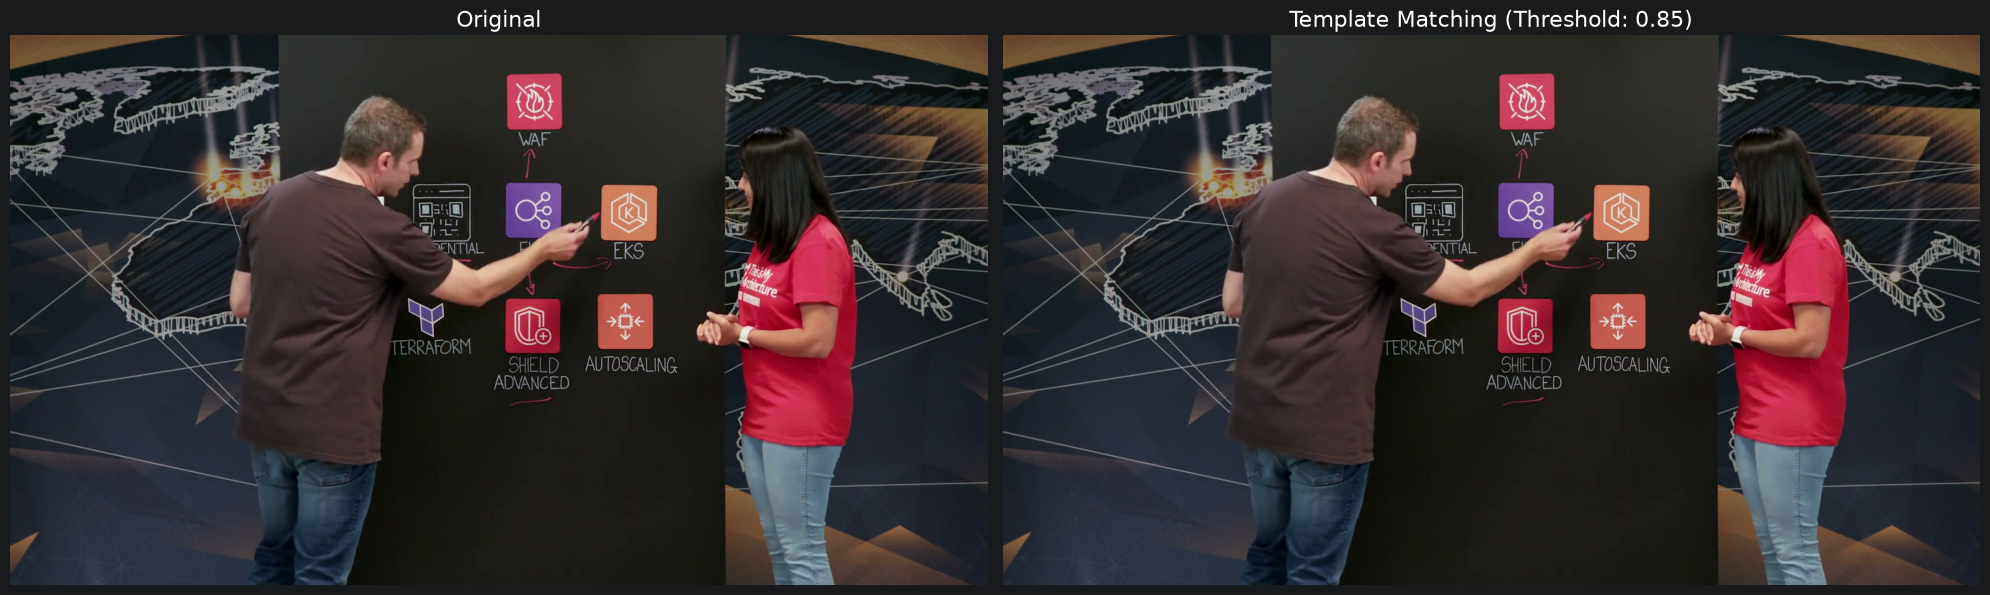

In [17]:
ruta_templates_dir = '/home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/templates'

visualizar_template_matching(imagen_bgr, imagen_rgb, ruta_templates_dir, threshold=0.85)

## Symbol_Detector

Este script es una evolución mucho más robusta de tu buscador de íconos anterior. Es un detector de símbolos diseñado específicamente para lidiar con las imperfecciones del dibujo a mano en las pizarras.

Sus superpoderes principales son:

Detección Multiescala (El cambio más importante): A diferencia del algoritmo anterior que solo buscaba íconos exactamente del mismo tamaño que la plantilla, este redimensiona cada plantilla 21 veces (desde la mitad de su tamaño hasta 2.5 veces más grande) usando la lista SCALES_TO_TEST. Esto asegura que detectará un ícono sin importar si el presentador lo dibujó diminuto o gigante.

Agrupación Inteligente de Servicios: Extrae el "nombre base" del servicio a partir del nombre del archivo (ej. si tu archivo se llama s3_variante1.png, entiende que el servicio es s3).

Doble Limpieza (NMS): Primero limpia detecciones duplicadas de una misma plantilla en un mismo tamaño, y luego hace una segunda limpieza entre diferentes formas del mismo servicio para no contar el mismo dibujo dos veces si hace "match" con dos plantillas parecidas de tu base de datos.

(Extra) Filtro por Transcripción: Tiene funciones preparadas para leer lo que el presentador dijo (transcript) y buscar solo los íconos de los servicios que mencionó, aunque en este bloque específico esa función está apagada por defecto para escanearlo todo.

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Escalas para buscar íconos de distintos tamaños
SCALES_TO_TEST = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5]

def non_max_suppression(boxes: list[tuple[int, int, int, int, float]], overlap_thresh: float = 0.3) -> list[tuple[int, int, int, int, float]]:
    """Limpia cajas delimitadoras superpuestas."""
    if not boxes:
        return []

    boxes_arr = np.array(boxes, dtype=np.float32)
    x1, y1 = boxes_arr[:, 0], boxes_arr[:, 1]
    x2, y2 = boxes_arr[:, 2], boxes_arr[:, 3]
    scores = boxes_arr[:, 4]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h

        denom = (areas[i] + areas[order[1:]] - inter)
        iou = np.zeros_like(inter)
        valid = denom > 0
        iou[valid] = inter[valid] / denom[valid]

        inds = np.where(iou <= overlap_thresh)[0]
        order = order[inds + 1]

    return [boxes[i] for i in keep]


def visualizar_detector_simbolos(img, img_rgb, ruta_templates_dir, threshold=0.75):
    """
    Busca símbolos en múltiples escalas y visualiza los recuadros finales.
    """
    if img is None or img_rgb is None:
        print("❌ ERROR: La imagen es nula.")
        return

    templates_dir = Path(ruta_templates_dir)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Cargar plantillas y agrupar por nombre base
    templates = {}
    if templates_dir.exists():
        for p in templates_dir.glob("*"):
            if p.suffix.lower() not in [".png", ".jpg"] or p.name.startswith("verify_crops"):
                continue

            stem_lower = p.stem.lower()
            # Asume que tus archivos se llaman ej. "s3_icon.png", tomando "s3" como servicio base
            base_service = stem_lower.split("_")[0]

            t_img_gray = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            templates[p.stem] = {
                "base_service": base_service,
                "img": t_img_gray
            }

    if not templates:
        print(f"❌ ERROR: No se encontraron plantillas válidas en {templates_dir}")
        return

    print(f"🔄 Procesando {len(templates)} plantillas en {len(SCALES_TO_TEST)} escalas diferentes...")

    service_boxes = {}

    # 2. Búsqueda Multiescala
    for t_name, t_data in templates.items():
        t_img = t_data["img"]
        base_service = t_data["base_service"]
        template_boxes = []

        for scale in SCALES_TO_TEST:
            w = int(t_img.shape[1] * scale)
            h = int(t_img.shape[0] * scale)
            if w > img_gray.shape[1] or h > img_gray.shape[0] or w == 0 or h == 0:
                continue

            resized_t = cv2.resize(t_img, (w, h))
            res = cv2.matchTemplate(img_gray, resized_t, cv2.TM_CCOEFF_NORMED)

            res_dilated = cv2.dilate(res, np.ones((5, 5)))
            local_max = (res == res_dilated) & (res >= threshold)
            y_coords, x_coords = np.where(local_max)

            for y, x in zip(y_coords, x_coords):
                score = float(res[y, x])
                template_boxes.append((x, y, x + w, y + h, score))

        # NMS por plantilla individual
        keep_boxes = non_max_suppression(template_boxes, overlap_thresh=0.3)
        if keep_boxes:
            if base_service not in service_boxes:
                service_boxes[base_service] = []
            for bx1, by1, bx2, by2, score in keep_boxes:
                service_boxes[base_service].append((bx1, by1, bx2, by2, score))

    # 3. NMS Final agrupado por servicio base
    final_detections = {}
    debug_img = img_rgb.copy()
    total_encontrados = 0

    # Usaremos una paleta de colores simples para diferenciar servicios
    colores = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]

    for i, (service, raw_boxes) in enumerate(service_boxes.items()):
        keep_boxes = non_max_suppression(raw_boxes, overlap_thresh=0.4)
        final_detections[service] = keep_boxes
        total_encontrados += len(keep_boxes)

        color = colores[i % len(colores)]

        for bx1, by1, bx2, by2, score in keep_boxes:
            # Dibujar rectángulos y texto en la imagen de visualización
            cv2.rectangle(debug_img, (int(bx1), int(by1)), (int(bx2), int(by2)), color, 3)
            etiqueta = f"{service.upper()} ({score:.2f})"
            cv2.putText(debug_img, etiqueta, (int(bx1), int(by1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)

    # 4. Mostrar Resultados
    print(f"🎯 Total de servicios detectados tras limpieza: {total_encontrados}")

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Original', fontsize=16)
    axes[0].axis('off')

    axes[1].imshow(debug_img)
    axes[1].set_title(f'Detector Multiescala (Umbral: {threshold})', fontsize=16)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

🔄 Procesando 29 plantillas en 21 escalas diferentes...
🎯 Total de servicios detectados tras limpieza: 2


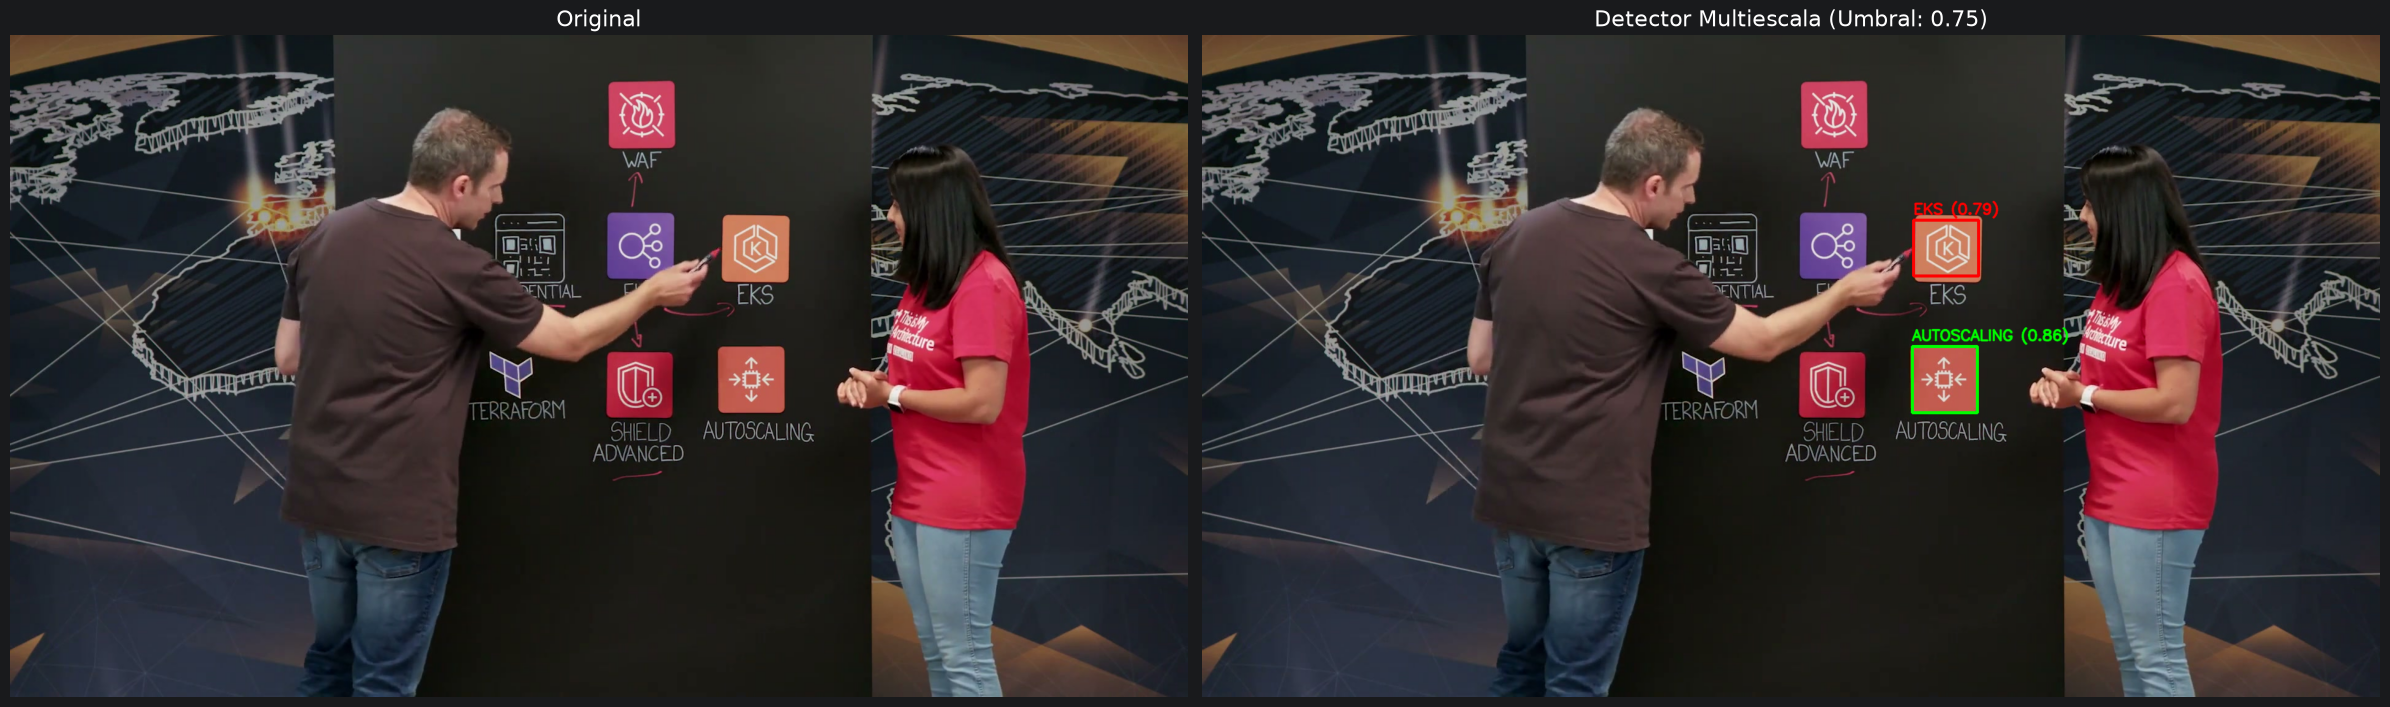

In [19]:
# Carga las variables
img_bgr, img_rgb = cargar_imagen(ruta_imagen_2)

# Ejecuta el detector (nota que el threshold es 0.75 por defecto en este script)
visualizar_detector_simbolos(img_bgr, img_rgb, ruta_templates_dir, threshold=0.75)

## pizarra_filter


¡Claro que sí! Este script (`pizarra_filter.py`) actúa como el **"portero inteligente"** de tu proyecto.

Su trabajo principal es revisar todos los fotogramas (imágenes) extraídos de un video y separar **únicamente aquellos donde realmente se está enfocando la pizarra**, descartando la basura (intros, outros, pantallas negras, o tomas donde se ve al público).

Aquí tienes el desglose de sus superpoderes paso a paso:

### 1. Inteligencia de Tiempo (Usa la transcripción)

Antes de analizar imágenes, el algoritmo lee el archivo de texto generado por la IA (Whisper). Busca en qué segundo exacto el presentador dejó de hablar (`last_speech_end`). Cualquier fotograma que aparezca después de ese momento es descartado automáticamente, porque asume que son los créditos finales o la pantalla de despedida.

### 2. Filtro de Pizarra (Análisis de Píxeles Oscuros)

Como las pizarras de AWS (blackboards) suelen ser oscuras, el script convierte la imagen a blanco y negro y calcula qué porcentaje de la pantalla está compuesto por **píxeles oscuros** (valor menor a 45).

* **Ajuste adaptable:** Curiosamente, el algoritmo busca en un archivo `.csv` qué tan viejo es el video. Si el video es reciente, exige que el **38%** de la pantalla sea oscura. Si es un video viejo (hace 1 año o más), exige un **75%**, probablemente porque la iluminación o el estilo de grabación de AWS cambió con el tiempo.
* Si la imagen cumple con ese porcentaje de oscuridad (y no es una pantalla 100% negra de transición), la considera un fotograma válido de la pizarra y la copia a una nueva carpeta.

### 3. Filtro de Outros (Scripts externos)

Llama a otro de tus scripts (`pizarra_outro_filter.py`) para darle una segunda pasada y asegurarse de que no se coló ninguna pantalla de marca corporativa de AWS entre las imágenes aprobadas.

### 4. Detección de Cambios (El Reporte HTML)

Esta es la parte más analítica. Una vez que tiene todas las fotos de la pizarra, agarra la imagen 1 y la compara con la imagen 2.

* Para hacerlo rápido, las encoge al tamaño de un sello postal (256x144 píxeles).
* Calcula el **MAE (Mean Absolute Error)**, que es básicamente la diferencia matemática de color entre ambas.
* Si la diferencia es menor a `8.0`, dice: *"Estas dos imágenes son casi idénticas, el presentador no ha dibujado nada nuevo (Posible duplicado)"*.
* Si es mayor, dice: *"Hubo un cambio significativo, hay un nuevo dibujo en la pizarra"*.
* Al final, escupe todo esto en un reporte `HTML` visual para que un humano (tú) pueda abrirlo en el navegador y ver el antes y después de cada cambio.

---

En resumen: **Limpia la paja del trigo.** Se asegura de que los scripts más pesados que corras después (como el detector de íconos Multiescala que vimos antes) no pierdan tiempo analizando intros, outros o 500 fotos idénticas donde el presentador no dibujó nada nuevo.

¿Te gustaría que te prepare una versión reducida de esta lógica (específicamente la parte que compara dos imágenes y calcula el MAE) para que puedas probarla directamente en tu Jupyter Notebook con un par de imágenes?

## frame_selector



Este script (`frame_selector.py`) es prácticamente la **joya de la corona** de tu pipeline de extracción de imágenes.

En versiones anteriores de tu proyecto, tenías scripts separados para filtrar pizarras y detectar la oclusión. Este script unifica todo eso en un **solo proceso automático e inteligente** para elegir el **fotograma perfecto** (el "Best Frame") que finalmente se enviará a Gemini (o cualquier otro LLM) para que analice la arquitectura.

En lugar de usar la técnica básica de "agarrar la última imagen del video", este algoritmo actúa como un director de fotografía. Aquí tienes cómo piensa, paso a paso:

### 1. El Recorte de Tiempo y Basura (Fase de Descarte)

* **Ignora el principio:** Asume que la arquitectura se construye con el tiempo, así que solo analiza el último 60% del video.
* **Usa la IA de texto:** Lee la transcripción para saber exactamente en qué segundo el presentador dejó de hablar. Si una imagen aparece después de ese segundo, la descarta (porque probablemente sean los créditos finales o sugerencias de YouTube).
* **Detector de Créditos:** Si la pantalla está muy oscura pero no tiene los colores vibrantes típicos de los íconos de AWS, sabe que es una pantalla de "Thank you for watching" o un logo corporativo, y la tira a la basura.

### 2. El Detector de "Arte" (Fase de Puntuación de Contenido)

A los fotogramas sobrevivientes les pone una nota (score) buscando dos cosas:

* **Íconos de AWS:** Los íconos de AWS son muy particulares: son cuadritos muy saturados y coloridos (naranjas, rosas, azules). El script usa un filtro de color (HSV) para contar cuántos "manchones" coloridos y cuadrados hay en la pantalla.
* **Líneas y Texto:** Usa un algoritmo clásico llamado `Canny Edge Detection` para ver cuántas líneas o bordes hay dibujados en el centro de la pizarra (flechas, nombres de servicios, bases de datos).
* **Bono de tiempo:** Si la imagen está más cerca del final del video, le da puntos extra asumiendo que el diagrama está más completo.

### 3. El Filtro Anti-Humanos (Fase de Oclusión)

Toma a los 10 mejores candidatos de la fase anterior y se hace una pregunta clave: *"¿El diagrama está genial, pero el presentador lo está tapando con su cuerpo?"*

* Hace un truco muy inteligente: primero oculta los íconos de AWS que ya detectó para no confundirlos.
* Luego, busca colores de piel humana y "columnas verticales" que rompan con el color oscuro de la pizarra (la ropa del presentador).
* Si detecta que hay una gran columna humana tapando el centro, **penaliza** la puntuación de esa imagen.

### 4. La Coronación

Finalmente, toma la puntuación de contenido, le resta la penalización de oclusión (el humano tapando), y el fotograma que quede con la nota más alta es declarado el ganador. Lo copia a tu carpeta final como `best_whiteboard.jpg`.

---

Es un enfoque fantástico porque no depende de modelos de IA súper pesados para cada imagen, sino de heurísticas de visión por computadora rápidas y efectivas.

¿Te gustaría que te extraiga un pequeño bloque de código de la **Fase 2 (El Detector de Arte)** para que puedas probar en tu Jupyter Notebook cómo la computadora resalta y detecta automáticamente esos "manchones coloridos" de los íconos de AWS?

### El detector de Pantallas de Creditos

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analizar_pantalla_creditos(img, img_rgb):
    """
    Evalúa si la imagen es una pantalla negra de transición o una pantalla de créditos.
    """
    if img is None:
        print("❌ Imagen nula.")
        return

    h, w = img.shape[:2]
    total_px = h * w
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 1. ¿Es una pantalla 100% negra de transición?
    mean_val = np.mean(gray)
    es_transicion = mean_val < 8.0

    # 2. Análisis de colores saturados (Mágia para detectar diagramas)
    sat_mask = (hsv[:, :, 1] > 80) & (hsv[:, :, 2] > 60)
    sat_pct = np.sum(sat_mask) / total_px

    # 3. Análisis de oscuridad general
    dark_pct = np.sum(gray < 50) / total_px
    std_dev = np.std(gray)

    # Lógica de decisión
    es_logo = std_dev < 20 and mean_val < 60
    es_credito = dark_pct > 0.70 and sat_pct < 0.08
    es_basura = es_transicion or es_logo or es_credito

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(img_rgb)
    titulo = "🚫 DESCARTADA (Créditos/Transición)" if es_basura else "✅ APROBADA (Posible Pizarra)"
    color = "red" if es_basura else "green"
    axes[0].set_title(titulo, fontsize=16, color=color, fontweight='bold')
    axes[0].axis('off')

    # Mostrar la máscara de saturación para ver qué colores detectó
    axes[1].imshow(sat_mask, cmap='gray')
    axes[1].set_title(f'Píxeles Vibrantes (Sat > 80, Val > 60)\nSaturación: {sat_pct:.3%} | Oscuridad: {dark_pct:.1%}', fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# --- PARA PROBARLO ---
# img_bgr, img_rgb = cargar_imagen('ruta_a_una_imagen_de_creditos.jpg')
# analizar_pantalla_creditos(img_bgr, img_rgb)

### El "Detector de Arte" (Scoring de Contenido)

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualizar_detector_arte(img, img_rgb):
    """
    Calcula el puntaje de contenido buscando manchas de color (íconos)
    y densidad de líneas (dibujos en tiza/marcador).
    """
    if img is None:
        return

    h, w = img.shape[:2]
    total_px = h * w
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    debug_img = img_rgb.copy()

    # ---------------------------------------------------------
    # 1. BUSCADOR DE ÍCONOS (Manchas de color saturado)
    # ---------------------------------------------------------
    sat_mask = (hsv[:, :, 1] > 80) & (hsv[:, :, 2] > 60)
    sat_uint8 = sat_mask.astype(np.uint8) * 255

    # Limpiar ruido y unir píxeles cercanos (Morphology)
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    opened = cv2.morphologyEx(sat_uint8, cv2.MORPH_OPEN, kernel_open)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    icon_count = 0
    for cnt in contours:
        x, y, cw, ch = cv2.boundingRect(cnt)

        # Filtros de tamaño para evitar detectar puntitos o toda la pantalla
        min_side = min(h, w) * 0.02
        max_side = min(h, w) * 0.25

        if cw < min_side or ch < min_side or cw > max_side or ch > max_side:
            continue

        aspect = cw / ch if ch > 0 else 0

        # Si es medio cuadrado (relación de aspecto entre 0.3 y 3.0)
        if 0.3 < aspect < 3.0:
            icon_count += 1
            # Dibujar un recuadro cyan para mostrar lo que detectó como ícono
            cv2.rectangle(debug_img, (x, y), (x + cw, y + ch), (0, 255, 255), 3)

    sat_pct = np.sum(sat_mask) / total_px
    icon_score = min(icon_count / 10.0, 1.0)
    area_score = min(sat_pct * 20, 1.0)
    color_score = 0.6 * icon_score + 0.4 * area_score

    # ---------------------------------------------------------
    # 2. BUSCADOR DE DIBUJOS (Densidad de Bordes)
    # ---------------------------------------------------------
    roi_x1, roi_x2 = int(w * 0.15), int(w * 0.85)
    roi_y1, roi_y2 = int(h * 0.10), int(h * 0.90)
    roi = gray[roi_y1:roi_y2, roi_x1:roi_x2]

    # Detector de bordes Canny (líneas blancas sobre fondo negro)
    edges = cv2.Canny(roi, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size

    # Puntaje final
    final_score = 0.7 * color_score + 0.3 * min(edge_density * 10, 1.0)

    # ---------------------------------------------------------
    # Visualización
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Dibujar ROI amarillo
    cv2.rectangle(debug_img, (roi_x1, roi_y1), (roi_x2, roi_y2), (255, 255, 0), 2)

    axes[0].imshow(debug_img)
    axes[0].set_title(f'Detector de Íconos (Cyan)\nPuntaje Color: {color_score:.3f} | Encontrados: {icon_count}', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(edges, cmap='magma')
    axes[1].set_title(f'Detector de Dibujos (Canny Edges)\nDensidad de Tiza: {edge_density:.3%} | Score Total: {final_score:.3f}', fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# --- PARA PROBARLO ---
# img_bgr, img_rgb = cargar_imagen('ruta_a_una_imagen_buena.jpg')
# visualizar_detector_arte(img_bgr, img_rgb)

## pizarra_outro_filter

Este script (`pizarra_outro_filter.py`) actúa como tu **"Filtro Anti-Logos"** o el guardia de seguridad final para tu carpeta de imágenes de la pizarra.

Su único objetivo es detectar y eliminar automáticamente esas pantallas corporativas de introducción y despedida (como el logo de *"This is My Architecture"* o el mensaje de *"Thank you for watching"*).

El problema que resuelve es que esas pantallas de créditos **también tienen un fondo oscuro**, por lo que pueden engañar a tu primer filtro (el que buscaba fondos negros). Para no confundir a la IA más adelante con un logo corporativo en lugar de un diagrama, este algoritmo usa tres reglas visuales muy astutas sin necesidad de leer texto:

### ¿Cómo funciona la magia? (Las 3 Reglas)

Toda la lógica pesada ocurre en la función `_is_branded_screen`, que analiza la imagen buscando estas tres pistas:

1. **Ausencia de Humanos (Porcentaje de piel):** Un diagrama de arquitectura real en video *siempre* tiene al presentador parado al lado. El algoritmo busca píxeles con tonos de piel humana (usando rangos de color HSV). Si detecta que menos del **1.5%** de la imagen tiene tonos de piel, levanta la primera bandera roja: *"Aquí no hay nadie, debe ser una diapositiva de texto"*.
2. **Distribución de Luz (Bordes oscuros):** Corta la imagen en columnas y mide el brillo. Las pantallas de créditos suelen tener fondos completamente negros en los extremos. Si el 15% del borde izquierdo y el 15% del borde derecho son extremadamente oscuros (brillo menor a 32.0), levanta la segunda bandera roja.
3. **Contraste Centro vs. Lados:** Esta es la heurística más inteligente. En una pantalla de introducción, **el centro está iluminado** (por el logo blanco/naranja) y los lados son negros. En un video de pizarra real es al revés: **el centro es oscuro** (la pizarra negra) y los lados suelen ser más brillantes (las luces del estudio o la pared de fondo). Si el algoritmo nota que el centro tiene más luz que los costados, levanta la tercera bandera roja.

### El Veredicto Final

Para evitar borrar una imagen útil por accidente, el script es precavido. Solo clasifica una imagen como `OUTRO` (y la elimina físicamente de tu disco duro) si cumple **al menos 2 de las 3 razones anteriores** (y obliga a que al menos una de esas razones sea un problema con la iluminación lateral).

Si pasas el argumento `--dry-run` en la terminal, el script solo simulará el proceso y te imprimirá en consola cuáles imágenes borraría y por qué, pero sin tocar tus archivos. ¡Es un excelente filtro de limpieza para dejarle el camino libre a tu detector de íconos multiescala!

# Pruebas

In [16]:
import cv2
import shutil
import os
from pathlib import Path

# ==========================================
# 1. CONFIGURACIÓN DEL LABORATORIO
# ==========================================
# Cambia este ID por el video que quieras analizar
VIDEO_ID = "A4Lfk1Zz1dE"

# Rutas absolutas basadas en tu estructura
PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
LAB_DIR = PROJECT_ROOT / 'whiteboard_selection_lab'

# Nuevas carpetas de destino para las pruebas
FRAMES_NEW_DIR = LAB_DIR / 'frames_new' / VIDEO_ID
TRANSCRIPTIONS_DIR = LAB_DIR / 'transcriptions'

def preparar_entorno_prueba(video_id):
    """Crea directorios, copia transcripciones y extrae frames con velocidad dinámica."""
    print(f"🚀 Iniciando preparación para el video: {video_id}")

    # 2. CREACIÓN DE CARPETAS
    FRAMES_NEW_DIR.mkdir(parents=True, exist_ok=True)
    TRANSCRIPTIONS_DIR.mkdir(parents=True, exist_ok=True)
    print(f"✅ Carpetas creadas:\n  - {FRAMES_NEW_DIR}\n  - {TRANSCRIPTIONS_DIR}")

    # Limpiar frames anteriores de esta carpeta si existen (para evitar mezclas)
    for f in FRAMES_NEW_DIR.glob('*.jpg'):
        f.unlink()

    # 3. COPIAR LA TRANSCRIPCIÓN
    transcript_origen = RAW_DIR / f"{video_id}_transcript.json"
    transcript_destino = TRANSCRIPTIONS_DIR / f"{video_id}_transcript.json"

    if transcript_origen.exists():
        shutil.copy(transcript_origen, transcript_destino)
        print(f"✅ Transcripción copiada a la carpeta de pruebas.")
    else:
        print(f"⚠️ ADVERTENCIA: No se encontró la transcripción en {transcript_origen}")

    # 4. EXTRACCIÓN DE FRAMES DINÁMICA (10s al inicio, 1s al final)
    video_path = RAW_DIR / f"{video_id}.mp4"

    if not video_path.exists():
        print(f"❌ ERROR: No se encontró el video en {video_path}")
        return

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"❌ ERROR: No se pudo abrir el video.")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        fps = 30.0 # Fallback por si OpenCV falla en leer los FPS

    # Obtener el total de frames para calcular el 80%
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    umbral_80_porciento = int(total_frames * 0.80)

    # Definir los dos intervalos
    intervalo_lento = int(fps * 10) # Cada 10 segundos
    intervalo_rapido = int(fps * 1)  # Cada 1 segundo

    frame_count = 0
    saved_count = 0

    print(f"🎞️ Extrayendo frames... (FPS: {fps:.2f}, Total frames: {total_frames})")
    print(f"   ⏱️ Del 0% al 80%: Cada 10s")
    print(f"   ⏱️ Del 80% al 100%: Cada 1s")

    while True:
        ret, frame = cap.read()
        if not ret:
            break # Fin del video

        # Determinar qué intervalo usar dependiendo de en qué parte del video estamos
        intervalo_actual = intervalo_lento if frame_count < umbral_80_porciento else intervalo_rapido

        # Guardar si cumple el intervalo correspondiente
        if frame_count % intervalo_actual == 0:
            nombre_archivo = f"{video_id}_frame_{frame_count}.jpg"
            ruta_guardado = FRAMES_NEW_DIR / nombre_archivo
            cv2.imwrite(str(ruta_guardado), frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    print(f"🎯 ¡Listo! Se extrajeron {saved_count} frames en total.")
    print(f"📁 Revisa la carpeta: {FRAMES_NEW_DIR}")

# Ejecutar la función
preparar_entorno_prueba(VIDEO_ID)

🚀 Iniciando preparación para el video: A4Lfk1Zz1dE
✅ Carpetas creadas:
  - /home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/frames_new/A4Lfk1Zz1dE
  - /home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/transcriptions
✅ Transcripción copiada a la carpeta de pruebas.
🎞️ Extrayendo frames... (FPS: 29.97, Total frames: 7295)
   ⏱️ Del 0% al 80%: Cada 10s
   ⏱️ Del 80% al 100%: Cada 1s
🎯 ¡Listo! Se extrajeron 70 frames en total.
📁 Revisa la carpeta: /home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/frames_new/A4Lfk1Zz1dE


In [9]:

import json
import shutil
import cv2
from pathlib import Path

# ==========================================
# 1. RUTAS Y CONFIGURACIÓN
# ==========================================
VIDEO_ID = "QJZHs1CSxu0"

PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
LAB_DIR = PROJECT_ROOT / 'whiteboard_selection_lab'

# Carpetas de origen y destino
FRAMES_DIR = LAB_DIR / 'frames_new' / VIDEO_ID
TRANSCRIPT_PATH = LAB_DIR / 'transcriptions' / f"{VIDEO_ID}_transcript.json"
WHISPER_REJECT_DIR = FRAMES_DIR / f"{VIDEO_ID}_whisper"

def probar_filtro_whisper(video_id):
    print(f"🕵️ Iniciando Filtro de Tiempo (Whisper) para: {video_id}")

    # 2. CREAR CARPETA DE RECHAZADOS
    WHISPER_REJECT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"📁 Carpeta de descartes creada en: {WHISPER_REJECT_DIR.name}/")

    # 3. LEER EL ÚLTIMO SEGUNDO HABLADO
    if not TRANSCRIPT_PATH.exists():
        print(f"❌ ERROR: No se encontró la transcripción en {TRANSCRIPT_PATH}")
        return

    with open(TRANSCRIPT_PATH, "r", encoding="utf-8") as f:
        segmentos = json.load(f)

    if not segmentos:
        print("❌ La transcripción está vacía.")
        return

    ultimo_segundo_hablado = segmentos[-1].get("end")
    print(f"🎙️ Última palabra detectada en el segundo: {ultimo_segundo_hablado:.2f}s")

    # 4. OBTENER LOS FPS DEL VIDEO ORIGINAL
    video_path = RAW_DIR / f"{video_id}.mp4"
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()

    # 5. FILTRAR Y MOVER
    frames = sorted(FRAMES_DIR.glob(f"{video_id}_frame_*.jpg"))
    movidos_count = 0

    for fp in frames:
        # Extraer el número de frame del nombre del archivo
        try:
            frame_num = int(fp.stem.split("_frame_")[-1])
        except ValueError:
            continue

        # Calcular en qué segundo del video ocurre este frame
        tiempo_frame_segundos = frame_num / fps

        # Si el frame aparece DESPUÉS de que el presentador dejó de hablar...
        # (Puedes sumarle +2 o +3 a ultimo_segundo_hablado si ves que corta muy al ras)
        if tiempo_frame_segundos > ultimo_segundo_hablado:
            destino = WHISPER_REJECT_DIR / fp.name
            shutil.move(str(fp), str(destino))
            movidos_count += 1

    print(f"🎯 ¡Listo! Se movieron {movidos_count} frames a la carpeta de descartes.")
    print(f"👀 Revisa la carpeta {WHISPER_REJECT_DIR.name}/ para ver si cortó bien.")

# Ejecutar la prueba
probar_filtro_whisper(VIDEO_ID)

🕵️ Iniciando Filtro de Tiempo (Whisper) para: QJZHs1CSxu0
📁 Carpeta de descartes creada en: QJZHs1CSxu0_whisper/
🎙️ Última palabra detectada en el segundo: 217.84s
🎯 ¡Listo! Se movieron 0 frames a la carpeta de descartes.
👀 Revisa la carpeta QJZHs1CSxu0_whisper/ para ver si cortó bien.


In [11]:
import json
import pandas as pd
import cv2
import numpy as np
import shutil
from pathlib import Path

# ==========================================
# 1. RUTAS Y CONFIGURACIÓN
# ==========================================
VIDEO_ID = "QJZHs1CSxu0" # Mismo ID que estamos usando

PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
LAB_DIR = PROJECT_ROOT / 'whiteboard_selection_lab'
CSV_PATH = PROJECT_ROOT / 'videos.csv'

# Carpetas de origen y destino
FRAMES_DIR = LAB_DIR / 'frames_new' / VIDEO_ID
OUTROS_REJECT_DIR = FRAMES_DIR / f"{VIDEO_ID}_outros"

def get_video_age_from_csv(video_id: str) -> str:
    """Busca la edad del video usando info.json y videos.csv"""
    info_path = RAW_DIR / f"{video_id}.info.json"

    if not info_path.exists() or not CSV_PATH.exists():
        return "unknown"

    try:
        with open(info_path, "r", encoding="utf-8") as f:
            info = json.load(f)

        title = info.get("title", "").strip().lower()
        if not title:
            return "unknown"

        df = pd.read_csv(CSV_PATH)
        title_clean = "".join(title.split()).replace(":", "").replace("-", "")

        for _, row in df.iterrows():
            row_title = str(row["title"]).strip().lower()
            row_title_clean = "".join(row_title.split()).replace(":", "").replace("-", "")

            if title_clean in row_title_clean or row_title_clean in title_clean:
                return str(row["age"]).strip()
    except Exception as e:
        print(f"Error leyendo CSV: {e}")

    return "unknown"

def _is_branded_screen(img: np.ndarray) -> tuple[bool, list[str]]:
    """Lógica original de detección de Outros/Logos"""
    h, w, _ = img.shape
    reasons = []

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Porcentaje de piel (Si no hay piel humana = bandera roja)
    skin_mask = cv2.inRange(hsv, (0, 40, 80), (25, 170, 255))
    skin_pct = (np.sum(skin_mask > 0) / skin_mask.size) * 100
    if skin_pct < 1.5:
        reasons.append(f"baja piel ({skin_pct:.2f}%)")

    # 2. Distribución de brillo
    col_means = np.mean(gray, axis=0)
    left_bright = np.mean(col_means[:int(w * 0.15)])
    center_bright = np.mean(col_means[int(w * 0.35):int(w * 0.65)])
    right_bright = np.mean(col_means[int(w * 0.85):])

    svc = ((left_bright + right_bright) / 2) - center_bright

    if left_bright < 32.0 and right_bright < 32.0:
        reasons.append(f"lados oscuros (L={left_bright:.1f}, R={right_bright:.1f})")
    if svc < -5.0:
        reasons.append(f"centro más brillante que lados ({svc:.1f})")

    # Es outro si tiene 2 banderas rojas y una de ellas es problema de luz
    is_outro = len(reasons) >= 2 and (svc < -5.0 or (left_bright < 32.0 and right_bright < 32.0))

    return is_outro, reasons

def probar_filtro_outros(video_id):
    print(f"🛡️ Iniciando Filtro de Outros/Logos para: {video_id}")

    # 1. LEER CSV PARA DETERMINAR UMBRAL
    age = get_video_age_from_csv(video_id)
    if age == "hace 1 año" or age == "unknown":
        dark_threshold = 75.0
    else:
        dark_threshold = 38.0

    print(f"📄 Video referenciado. Edad: '{age}'.")
    print(f"🎚️ Usando umbral de oscuridad (dark_threshold) del {dark_threshold}%")

    # 2. CREAR CARPETA DE RECHAZADOS
    OUTROS_REJECT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"📁 Carpeta de descartes creada en: {OUTROS_REJECT_DIR.name}/")

    # 3. FILTRAR Y MOVER
    # Solo procesamos las imágenes que sobrevivieron al filtro de Whisper (si lo corriste antes)
    frames = sorted(FRAMES_DIR.glob("*.jpg"))
    movidos_count = 0

    print("\n🔍 Analizando imágenes...")
    for fp in frames:
        img = cv2.imread(str(fp))
        if img is None:
            continue

        h, w, c = img.shape
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Primero revisamos si la imagen cumple con el umbral de oscuridad de la pizarra
        dark_px_pct = (np.sum(gray < 45) / (h * w)) * 100

        # Si NO es lo suficientemente oscura, NO es una pizarra, la movemos
        if dark_px_pct < dark_threshold:
            destino = OUTROS_REJECT_DIR / fp.name
            shutil.move(str(fp), str(destino))
            movidos_count += 1
            print(f"  ❌ {fp.name} descartada: Muy clara ({dark_px_pct:.1f}% oscuridad < {dark_threshold}%)")
            continue

        # Si pasó la prueba de oscuridad, revisamos si es un Logo/Outro corporativo
        is_outro, reasons = _is_branded_screen(img)

        if is_outro:
            destino = OUTROS_REJECT_DIR / fp.name
            shutil.move(str(fp), str(destino))
            movidos_count += 1
            reason_str = ", ".join(reasons)
            print(f"  ❌ {fp.name} descartada: Detectada como Logo/Outro ({reason_str})")

    print(f"\n🎯 ¡Listo! Se movieron {movidos_count} frames a {OUTROS_REJECT_DIR.name}/")

# Ejecutar la prueba
probar_filtro_outros(VIDEO_ID)

🛡️ Iniciando Filtro de Outros/Logos para: QJZHs1CSxu0
📄 Video referenciado. Edad: 'hace 3 años'.
🎚️ Usando umbral de oscuridad (dark_threshold) del 38.0%
📁 Carpeta de descartes creada en: QJZHs1CSxu0_outros/

🔍 Analizando imágenes...
  ❌ QJZHs1CSxu0_frame_0.jpg descartada: Detectada como Logo/Outro (baja piel (0.00%), lados oscuros (L=0.0, R=0.1))
  ❌ QJZHs1CSxu0_frame_3887.jpg descartada: Muy clara (37.5% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_frame_5597.jpg descartada: Muy clara (37.5% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_frame_5626.jpg descartada: Muy clara (37.7% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_frame_5655.jpg descartada: Muy clara (37.6% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_frame_5684.jpg descartada: Muy clara (37.6% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_frame_5713.jpg descartada: Muy clara (37.4% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_frame_5742.jpg descartada: Muy clara (37.6% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_frame_5771.jpg descartada: Muy clara (37.5% oscuridad < 38.0%)
  ❌ QJZHs1CSxu0_fr

In [9]:
import json
import pandas as pd
import cv2
import numpy as np
import shutil
from pathlib import Path

# ==========================================
# 1. RUTAS Y CONFIGURACIÓN
# ==========================================
VIDEO_ID = "QJZHs1CSxu0"

PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
LAB_DIR = PROJECT_ROOT / 'whiteboard_selection_lab'
CSV_PATH = PROJECT_ROOT / 'videos.csv'

# Carpetas de origen y destino
FRAMES_DIR = LAB_DIR / 'frames_new' / VIDEO_ID
PIZARRA_DIR = LAB_DIR / 'frames_new' / f"{VIDEO_ID}_pizarra"

def get_video_age_from_csv(video_id: str) -> str:
    """Busca la edad del video usando info.json y videos.csv para ajustar el umbral."""
    info_path = RAW_DIR / f"{video_id}.info.json"

    if not info_path.exists() or not CSV_PATH.exists():
        return "unknown"

    try:
        with open(info_path, "r", encoding="utf-8") as f:
            info = json.load(f)

        title = info.get("title", "").strip().lower()
        if not title:
            return "unknown"

        df = pd.read_csv(CSV_PATH)
        title_clean = "".join(title.split()).replace(":", "").replace("-", "")

        for _, row in df.iterrows():
            row_title = str(row["title"]).strip().lower()
            row_title_clean = "".join(row_title.split()).replace(":", "").replace("-", "")

            if title_clean in row_title_clean or row_title_clean in title_clean:
                return str(row["age"]).strip()
    except Exception as e:
        print(f"Error leyendo CSV: {e}")

    return "unknown"

def probar_filtro_pizarra(video_id):
    print(f"🎬 Iniciando Filtro de Pizarra (Píxeles Oscuros) para: {video_id}")

    # 1. LEER CSV PARA DETERMINAR UMBRAL
    age = get_video_age_from_csv(video_id)
    if age == "hace 1 año" or age == "unknown":
        dark_threshold = 75.0
    else:
        dark_threshold = 38.0

    print(f"📄 Video detectado en CSV. Edad: '{age}'.")
    print(f"🎚️ Exigiendo un mínimo de {dark_threshold}% de píxeles oscuros por imagen.")

    # 2. CREAR CARPETA DE PIZARRAS APROBADAS
    PIZARRA_DIR.mkdir(parents=True, exist_ok=True)
    print(f"📁 Carpeta de pizarras creada en: {PIZARRA_DIR.name}/")

    # 3. ANALIZAR Y MOVER LAS IMÁGENES VÁLIDAS
    frames = sorted(FRAMES_DIR.glob("*.jpg"))
    aprobados_count = 0
    rechazados_count = 0

    print("\n🔍 Analizando fotogramas...")

    for fp in frames:
        img = cv2.imread(str(fp))
        if img is None:
            continue

        h, w, c = img.shape
        total_pixels = h * w
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Calcular porcentaje de oscuridad (píxeles con valor < 45) y el brillo general
        dark_px_pct = (np.sum(gray < 45) / total_pixels) * 100
        mean_val = np.mean(gray)

        # Regla de Seguridad: Ignorar pantallas de transición 100% negras
        if mean_val < 5.0 or dark_px_pct > 95.0:
            print(f"  ⏭️ Ignorada: {fp.name} (Transición en negro detectada)")
            rechazados_count += 1
            continue

        # Regla Principal: ¿Tiene suficientes píxeles oscuros para ser una pizarra?
        if dark_px_pct >= dark_threshold:
            # ¡ES UNA PIZARRA! La movemos a la carpeta de aprobadas.
            destino = PIZARRA_DIR / fp.name
            shutil.move(str(fp), str(destino))
            aprobados_count += 1
        else:
            # No cumple, se queda en la carpeta original como descarte.
            rechazados_count += 1

    print(f"\n✅ RESUMEN DEL FILTRO:")
    print(f"   🏆 Aprobadas (Movidas a {PIZARRA_DIR.name}): {aprobados_count} frames")
    print(f"   🗑️ Rechazadas (Se quedaron en origen): {rechazados_count} frames")

# Ejecutar la prueba
probar_filtro_pizarra(VIDEO_ID)

🎬 Iniciando Filtro de Pizarra (Píxeles Oscuros) para: 1ZLiRT0C2Yo
📄 Video detectado en CSV. Edad: 'hace 4 años'.
🎚️ Exigiendo un mínimo de 38.0% de píxeles oscuros por imagen.
📁 Carpeta de pizarras creada en: 1ZLiRT0C2Yo_pizarra/

🔍 Analizando fotogramas...

✅ RESUMEN DEL FILTRO:
   🏆 Aprobadas (Movidas a 1ZLiRT0C2Yo_pizarra): 157 frames
   🗑️ Rechazadas (Se quedaron en origen): 0 frames


In [11]:
def probar_filtro_adaptativo():
    STEP2_REJECT_DIR = LAB_DIR / 'frames_new' / f"{VIDEO_ID}_step2_adaptive_reject"
    STEP2_PASS_DIR = LAB_DIR / 'frames_new' / f"{VIDEO_ID}_step2_pass"

    STEP2_REJECT_DIR.mkdir(parents=True, exist_ok=True)
    STEP2_PASS_DIR.mkdir(parents=True, exist_ok=True)

    frames = sorted(STEP1_PASS_DIR.glob("*.jpg"))
    if not frames: return
    print(f"\n📏 Etapa 2: Umbral Adaptativo ({len(frames)} frames)")

    # 1. Encontrar la máxima oscuridad
    max_dark_pct = 0.0
    datos_frames = []

    for fp in frames:
        img = cv2.imread(str(fp))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        dark_pct = (np.sum(gray < 50) / gray.size) * 100
        max_dark_pct = max(max_dark_pct, dark_pct)
        datos_frames.append({"path": fp, "img": img, "gray": gray, "dark_pct": dark_pct})

    adaptive_threshold = 0.75 * max_dark_pct if max_dark_pct > 55.0 else 0.0
    print(f"🎛️ Oscuridad máxima encontrada: {max_dark_pct:.1f}%. Umbral fijado en: {adaptive_threshold:.1f}%")

    # 2. Filtrar y generar debug
    for data in datos_frames:
        rechazado = data["dark_pct"] < adaptive_threshold

        # Debug: Visualizar qué píxeles considera "oscuros" (valor < 50) marcados en rojo
        dark_mask = data["gray"] < 50
        debug_img = data["img"].copy()
        debug_img[dark_mask] = [0, 0, 255] # Rojo en BGR

        texto = f"Oscuridad: {data['dark_pct']:.1f}% (Umbral: {adaptive_threshold:.1f}%)"
        color = (0, 0, 255) if rechazado else (0, 255, 0)
        cv2.putText(debug_img, texto, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

        if rechazado:
            cv2.imwrite(str(STEP2_REJECT_DIR / f"debug_{data['path'].name}"), debug_img)
        else:
            shutil.copy(str(data["path"]), str(STEP2_PASS_DIR / data["path"].name))

    print(f"✅ Listo. Revisa {STEP2_REJECT_DIR.name}/ para ver quiénes no dieron la talla oscura.")

probar_filtro_adaptativo()


📏 Etapa 2: Umbral Adaptativo (119 frames)
🎛️ Oscuridad máxima encontrada: 49.7%. Umbral fijado en: 0.0%
✅ Listo. Revisa CE03UMddoYU_step2_adaptive_reject/ para ver quiénes no dieron la talla oscura.


In [12]:
import cv2
import numpy as np
from pathlib import Path

# Configuración inicial autónoma
VIDEO_ID = "1ZLiRT0C2Yo"
PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
LAB_DIR = PROJECT_ROOT / 'whiteboard_selection_lab'
FRAMES_DIR = LAB_DIR / 'frames_new' / VIDEO_ID  # <-- Leyendo de los originales

def probar_scoring_contenido_independiente():
    # Nueva carpeta para no mezclar
    STEP3_DIR = LAB_DIR / 'frames_new' / f"{VIDEO_ID}_step3_independiente_top10"
    STEP3_DIR.mkdir(parents=True, exist_ok=True)

    frames = sorted(FRAMES_DIR.glob("*.jpg"))
    if not frames:
        print("❌ No se encontraron frames originales.")
        return

    print(f"\n🎨 Etapa 3 (Aislada): Scoring de Contenido evaluando {len(frames)} frames crudos")
    scored_frames = []

    for fp in frames:
        img = cv2.imread(str(fp))
        if img is None: continue

        h, w = img.shape[:2]
        debug_img = img.copy()
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ---------------------------------------------------------
        # ZONA SEGURA (Modo Francotirador)
        # ---------------------------------------------------------
        roi_x1, roi_x2 = int(w * 0.28), int(w * 0.72)
        roi_y1, roi_y2 = int(h * 0.10), int(h * 0.82)

        # 1. Buscar Íconos (Color saturado SOLO en la pizarra central)
        sat_mask = (hsv[:, :, 1] > 80) & (hsv[:, :, 2] > 60)

        # Apagamos los píxeles de color que estén fuera de la zona segura
        sat_mask[:, :roi_x1] = False
        sat_mask[:, roi_x2:] = False
        sat_mask[:roi_y1, :] = False
        sat_mask[roi_y2:, :] = False

        sat_uint8 = sat_mask.astype(np.uint8) * 255
        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        opened = cv2.morphologyEx(sat_uint8, cv2.MORPH_OPEN, kernel_open)
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        icon_count = 0
        for cnt in contours:
            x, y, cw, ch = cv2.boundingRect(cnt)

            # Ajuste de Área: Mínimo 5%, Máximo 15%
            min_side = min(h, w) * 0.05
            max_side = min(h, w) * 0.15

            if min_side < cw < max_side and min_side < ch < max_side:
                aspect = cw / ch if ch > 0 else 0

                # Ajuste de Forma: Forzamos que sea casi un cuadrado perfecto
                if 0.85 < aspect < 1.15:
                    icon_count += 1
                    cv2.rectangle(debug_img, (x, y), (x+cw, y+ch), (0, 255, 255), 4) # Cajas amarillas

        sat_pct = np.sum(sat_mask) / (h * w)
        color_score = 0.6 * min(icon_count / 10.0, 1.0) + 0.4 * min(sat_pct * 20, 1.0)

        # ---------------------------------------------------------
        # 2. Buscar Tiza (Líneas gruesas digitales SOLO en la zona segura)
        # ---------------------------------------------------------
        roi = gray[roi_y1:roi_y2, roi_x1:roi_x2]

        # MEJORA A: Desenfoque fuerte para matar el ruido fino (ropa, cabello)
        roi_blurred = cv2.medianBlur(roi, 7)

        # MEJORA B: Canny estricto para detectar líneas de alto contraste
        edges = cv2.Canny(roi_blurred, 80, 200)

        # MEJORA C: Engrosar los bordes para dar más peso a la tiza
        kernel_dilate = np.ones((3, 3), np.uint8)
        edges_thick = cv2.dilate(edges, kernel_dilate, iterations=1)

        edge_density = np.sum(edges_thick > 0) / edges_thick.size

        # Superponer bordes engrosados en la imagen debug (Púrpura)
        edges_bgr = np.zeros_like(img)
        edges_bgr[roi_y1:roi_y2, roi_x1:roi_x2][edges_thick > 0] = [255, 0, 255]
        cv2.addWeighted(edges_bgr, 1.0, debug_img, 1.0, 0, debug_img)

        # Superponer cuadro amarillo del ROI central
        cv2.rectangle(debug_img, (roi_x1, roi_y1), (roi_x2, roi_y2), (255, 255, 0), 2)

        # Ponderación: 70% Color + 30% Tiza
        content_score = 0.7 * color_score + 0.3 * min(edge_density * 10, 1.0)
        scored_frames.append({"path": fp, "score": content_score, "debug_img": debug_img})

    # Ordenar y guardar los 10 mejores de TODO el video
    scored_frames.sort(key=lambda x: x["score"], reverse=True)
    top_10 = scored_frames[:10]

    for i, data in enumerate(top_10):
        cv2.putText(data["debug_img"], f"Rank {i+1} | Score: {data['score']:.3f}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)
        cv2.imwrite(str(STEP3_DIR / f"rank{i+1}_{data['path'].name}"), data["debug_img"])

    print(f"✅ Listo. El Top 10 absoluto ha sido guardado en {STEP3_DIR.name}/")

probar_scoring_contenido_independiente()


🎨 Etapa 3 (Aislada): Scoring de Contenido evaluando 120 frames crudos
✅ Listo. El Top 10 absoluto ha sido guardado en CE03UMddoYU_step3_independiente_top10/


In [13]:
import cv2
import numpy as np
from pathlib import Path

# Configuración inicial autónoma
VIDEO_ID = "QJZHs1CSxu0"
PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
LAB_DIR = PROJECT_ROOT / 'whiteboard_selection_lab'
FRAMES_DIR = LAB_DIR / 'frames_new' / VIDEO_ID

def probar_filtro_oclusion_independiente():
    STEP4_DIR = LAB_DIR / 'frames_new' / f"{VIDEO_ID}_step4_independiente_oclusion"
    STEP4_DIR.mkdir(parents=True, exist_ok=True)

    frames = sorted(FRAMES_DIR.glob("*.jpg"))
    if not frames: return
    print(f"\n🧍 Etapa 4 (Aislada): Dibujando mapa de oclusión inteligente en {len(frames)} frames")

    for fp in frames:
        img = cv2.imread(str(fp))
        if img is None: continue

        h, w = img.shape[:2]
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # ---------------------------------------------------------
        # 1. ENMASCARAR SOLO LOS ÍCONOS CUADRADOS (Tu mejora)
        # ---------------------------------------------------------
        sat_mask = (hsv[:, :, 1] > 80) & (hsv[:, :, 2] > 60)
        sat_uint8 = sat_mask.astype(np.uint8) * 255

        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        opened = cv2.morphologyEx(sat_uint8, cv2.MORPH_OPEN, kernel_open)
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        img_masked = img.copy()

        for cnt in contours:
            x, y, cw, ch = cv2.boundingRect(cnt)
            min_side, max_side = min(h, w) * 0.05, min(h, w) * 0.15

            # Si es un cuadrado del tamaño de un ícono, lo pintamos de negro (lo ignoramos)
            if min_side < cw < max_side and min_side < ch < max_side:
                aspect = cw / ch if ch > 0 else 0
                if 0.85 < aspect < 1.15:
                    cv2.rectangle(img_masked, (x, y), (x+cw, y+ch), (0, 0, 0), -1)

        # ---------------------------------------------------------
        # 2. ESCÁNER DE HUMANOS (Modo Francotirador)
        # ---------------------------------------------------------
        # Solo escaneamos el centro (donde está el diagrama)
        roi_x1, roi_x2 = int(w * 0.28), int(w * 0.72)

        roi_hsv = cv2.cvtColor(img_masked[int(h*0.15):int(h*0.95), roi_x1:roi_x2], cv2.COLOR_BGR2HSV)
        roi_gray = cv2.cvtColor(img_masked[int(h*0.15):int(h*0.95), roi_x1:roi_x2], cv2.COLOR_BGR2GRAY)

        # Detectar tonos de piel
        skin_mask = cv2.inRange(roi_hsv, np.array([0, 30, 60]), np.array([25, 170, 255]))
        col_skin_pct = np.mean(skin_mask > 0, axis=0)

        # Detectar ropa (columnas que son significativamente más brillantes que el fondo)
        col_bright = np.mean(roi_gray, axis=0)
        dark_threshold = np.percentile(col_bright, 25)
        bright_cols = col_bright > (dark_threshold + 40)

        # Es humano si tiene piel, O si es un bulto brillante y tiene al menos un poco de piel (rostro/manos)
        occluded_cols = (col_skin_pct > 0.12) | (bright_cols & (col_skin_pct > 0.02))

        # Cerrar huecos (por si la ropa tiene partes oscuras)
        kernel = np.ones(int((roi_x2 - roi_x1) * 0.05), dtype=np.uint8)
        occluded_closed = cv2.morphologyEx(occluded_cols.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

        occlusion_pct = (np.sum(occluded_closed > 0) / len(occluded_closed)) * 100

        # ---------------------------------------------------------
        # 3. DEBUG VISUAL
        # ---------------------------------------------------------
        debug_img = img.copy()
        overlay = debug_img.copy()

        # Pintar las columnas ocluidas de rojo
        for x_idx in range(roi_x2 - roi_x1):
            if occluded_closed[x_idx] > 0:
                abs_x = roi_x1 + x_idx
                cv2.line(overlay, (abs_x, int(h*0.15)), (abs_x, int(h*0.95)), (0, 0, 255), 1)

        # Dibujar el ROI amarillo para ver la zona de peligro
        cv2.rectangle(overlay, (roi_x1, int(h*0.15)), (roi_x2, int(h*0.95)), (0, 255, 255), 2)

        cv2.addWeighted(overlay, 0.4, debug_img, 0.6, 0, debug_img)
        cv2.putText(debug_img, f"Oclusion Humana: {occlusion_pct:.1f}%", (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3)

        cv2.imwrite(str(STEP4_DIR / f"oclusion_{fp.name}"), debug_img)

    print(f"✅ Escáner de humanos optimizado. Revisa {STEP4_DIR.name}/")

probar_filtro_oclusion_independiente()


🧍 Etapa 4 (Aislada): Dibujando mapa de oclusión inteligente en 120 frames
✅ Escáner de humanos optimizado. Revisa CE03UMddoYU_step4_independiente_oclusion/


In [15]:
import cv2
import numpy as np
import shutil
import json
from pathlib import Path

# Configuración
VIDEO_ID = "A4Lfk1Zz1dE"
PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
FRAMES_DIR = PROJECT_ROOT / 'whiteboard_selection_lab' / 'frames_new' / VIDEO_ID
OUTPUT_DIR = FRAMES_DIR.parent / f"{VIDEO_ID}_FINAL_SELECTION"

def run_full_pipeline():
    OUTPUT_DIR.mkdir(exist_ok=True)

    # 1. Filtro Whisper (Cargar transcripción)
    transcript_path = PROJECT_ROOT / 'whiteboard_selection_lab' / 'transcriptions' / f"{VIDEO_ID}_transcript.json"
    last_speech = 99999
    if transcript_path.exists():
        with open(transcript_path, 'r') as f:
            segs = json.load(f)
            if segs: last_speech = segs[-1]['end']

    # 2. Carga y Filtro (Últimos 60%)
    all_frames = sorted(FRAMES_DIR.glob("*.jpg"), key=lambda p: int(p.stem.split("_frame_")[-1]))
    start_idx = int(len(all_frames) * 0.4)
    candidates = all_frames[start_idx:]

    scored_frames = []
    print(f"🚀 Procesando {len(candidates)} frames...")

    for fp in candidates:
        # Check Whisper inicial
        frame_num = int(fp.stem.split("_frame_")[-1])
        if (frame_num / 30.0) > last_speech + 10:
            continue

        img = cv2.imread(str(fp))
        if img is None: continue

        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # 1. Filtro de Outro/Logo
        col_means = np.mean(gray, axis=0)
        svc = ((np.mean(col_means[:int(w*0.15)]) + np.mean(col_means[int(w*0.85):])) / 2) - np.mean(col_means[int(w*0.35):int(w*0.65)])
        if svc < -5.0:
            scored_frames.append({"path": fp, "score": -999})
            continue

        # 2. Filtro de Oscuridad mínima
        dark_pct = np.sum(gray < 50) / (h * w)
        if dark_pct < 0.20:
            scored_frames.append({"path": fp, "score": -100})
            continue

        # 3. Oclusión: Pintar íconos cuadrados de negro para no confundirlos con humanos
        sat_mask = (hsv[:, :, 1] > 80) & (hsv[:, :, 2] > 60)
        contours, _ = cv2.findContours(sat_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        img_masked = img.copy()
        for cnt in contours:
            x, y, cw, ch = cv2.boundingRect(cnt)
            if 0.05*min(h,w) < cw < 0.15*min(h,w) and 0.85 < (cw/ch) < 1.15:
                cv2.rectangle(img_masked, (x, y), (x+cw, y+ch), (0,0,0), -1)

        # 4. Scorer de contenido (Tiza)
        roi = gray[int(h*0.1):int(h*0.9), int(w*0.28):int(w*0.72)]
        edges = cv2.Canny(cv2.medianBlur(roi, 7), 80, 200)
        edge_density = np.sum(edges > 0) / edges.size

        # 5. Piel humana
        skin = cv2.inRange(cv2.cvtColor(img_masked, cv2.COLOR_BGR2HSV), (0,30,60), (25,170,255))
        occlusion = np.mean(skin[int(h*0.15):int(h*0.95), int(w*0.28):int(w*0.72)])

        score = (edge_density * 50) - (occlusion * 5)
        scored_frames.append({"path": fp, "score": score})

    # 3. Selección Final
    scored_frames.sort(key=lambda x: x['score'], reverse=True)
    print(f"\n✅ Top 10 seleccionados:")
    for i, item in enumerate(scored_frames[:10]):
        rank = i + 1
        shutil.copy(item['path'], OUTPUT_DIR / f"Rank{rank}_{item['path'].name}")
        print(f"Rank {rank}: {item['path'].name} (Score: {item['score']:.2f})")

run_full_pipeline()

🚀 Procesando 0 frames...

✅ Top 10 seleccionados:


## Probar algoritmo completo

In [18]:
import cv2
import numpy as np
import shutil
from pathlib import Path

# Configuración
VIDEO_ID = "A4Lfk1Zz1dE"
PROJECT_ROOT = Path('/home/stemjara/Projects/AWS-Architecture')
FRAMES_DIR = PROJECT_ROOT / 'whiteboard_selection_lab' / 'frames_new' / VIDEO_ID
OUTPUT_DIR = FRAMES_DIR.parent / f"{VIDEO_ID}_FINAL_SELECTION"

def run_full_pipeline():
    OUTPUT_DIR.mkdir(exist_ok=True)

    # 1. Carga (Solo el último 40% del video, como solicitaste)
    all_frames = sorted(FRAMES_DIR.glob("*.jpg"), key=lambda p: int(p.stem.split("_frame_")[-1]))
    start_idx = int(len(all_frames) * 0.6) # Empezar en el 60%, analizar hasta el final
    candidates = all_frames[start_idx:]

    scored_frames = []
    print(f"🚀 Procesando {len(candidates)} frames (Último 40% del video)...")

    for fp in candidates:
        img = cv2.imread(str(fp))
        if img is None: continue

        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # ---------------------------------------------------------
        # FILTRO 1: ELIMINACIÓN DE PANTALLAS CLARAS
        # ---------------------------------------------------------
        dark_px_pct = np.sum(gray < 45) / (h * w)
        if dark_px_pct < 0.20:
            continue # ¡ELIMINADO! Ni siquiera lo guardamos.

        # ---------------------------------------------------------
        # FILTRO 2: ELIMINACIÓN DE OUTROS / LOGOS (Falta de piel)
        # ---------------------------------------------------------
        skin_mask = cv2.inRange(hsv, (0, 30, 60), (25, 170, 255))
        skin_pct = np.sum(skin_mask > 0) / skin_mask.size

        # Si no hay ni un 1.5% de piel humana, es un logo o texto 100% seguro.
        if skin_pct < 0.015:
            continue # ¡ELIMINADO!

        # ---------------------------------------------------------
        # SCORING (Solo llegan las verdaderas pizarras con humanos)
        # ---------------------------------------------------------
        # 1. Pintar íconos cuadrados de negro
        sat_mask = (hsv[:, :, 1] > 80) & (hsv[:, :, 2] > 60)
        contours, _ = cv2.findContours(sat_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        img_masked = img.copy()
        for cnt in contours:
            x, y, cw, ch = cv2.boundingRect(cnt)
            if 0.05*min(h,w) < cw < 0.15*min(h,w) and 0.85 < (cw/ch) < 1.15:
                cv2.rectangle(img_masked, (x, y), (x+cw, y+ch), (0,0,0), -1)

        # 2. Densidad de Tiza (Centro)
        roi_gray = gray[int(h*0.1):int(h*0.9), int(w*0.28):int(w*0.72)]
        edges = cv2.Canny(cv2.medianBlur(roi_gray, 7), 80, 200)
        edge_density = np.sum(edges > 0) / edges.size

        # 3. Penalización por Oclusión (Centro) - ¡BUG ARREGLADO!
        roi_skin = skin_mask[int(h*0.15):int(h*0.95), int(w*0.28):int(w*0.72)]
        # Ahora da un porcentaje real de 0.0 a 1.0 (en lugar de sumar 255s)
        occlusion = np.sum(roi_skin > 0) / roi_skin.size

        # Cálculo final
        score = (edge_density * 50) - (occlusion * 5)
        scored_frames.append({"path": fp, "score": score})

    # 3. Selección Final
    if not scored_frames:
        print("⚠️ Todos los frames fueron eliminados. Ninguno cumplió los requisitos.")
        return

    scored_frames.sort(key=lambda x: x['score'], reverse=True)

    # Limpiar carpeta de salida anterior
    for f in OUTPUT_DIR.glob("*.jpg"):
        f.unlink()

    print(f"\n✅ Top 10 seleccionados de las pizarras sobrevivientes:")
    for i, item in enumerate(scored_frames[:10]):
        rank = i + 1
        shutil.copy(item['path'], OUTPUT_DIR / f"Rank{rank}_{item['path'].name}")
        print(f"Rank {rank}: {item['path'].name} (Score: {item['score']:.2f})")

run_full_pipeline()

🚀 Procesando 28 frames (Último 40% del video)...

✅ Top 10 seleccionados de las pizarras sobrevivientes:
Rank 1: A4Lfk1Zz1dE_frame_6786.jpg (Score: 1.21)
Rank 2: A4Lfk1Zz1dE_frame_6757.jpg (Score: 1.21)
Rank 3: A4Lfk1Zz1dE_frame_6815.jpg (Score: 1.20)
Rank 4: A4Lfk1Zz1dE_frame_6844.jpg (Score: 1.20)
Rank 5: A4Lfk1Zz1dE_frame_6873.jpg (Score: 1.20)
Rank 6: A4Lfk1Zz1dE_frame_6960.jpg (Score: 1.20)
Rank 7: A4Lfk1Zz1dE_frame_7018.jpg (Score: 1.20)
Rank 8: A4Lfk1Zz1dE_frame_6699.jpg (Score: 1.19)
Rank 9: A4Lfk1Zz1dE_frame_6989.jpg (Score: 1.19)
Rank 10: A4Lfk1Zz1dE_frame_7076.jpg (Score: 1.19)
